# 1.19) Statistical foundations and the machine-learning stepping-stone

This closing subchapter connects descriptive statistics to a first supervised model. Using an environmental lapse rate — air temperature as a function of elevation — it moves from exploratory plots and correlation, through the scikit-learn estimator interface (instantiate, fit, predict), to an honest evaluation on held-out data with RMSE and the coefficient of determination. The estimator-as-object pattern is the one introduced in the object-oriented subchapter. The generated-code bug at the end is the mistake that quietly invalidates most first attempts at machine learning: judging a model by how well it fits the data it was trained on.

:::{admonition} Learning objectives
:class: tip
- Explore data with seaborn, and summarise it with descriptive statistics and correlation.
- Use the scikit-learn estimator interface: instantiate, fit, predict, with the X/y convention.
- Split data into train and test sets, and fit a linear regression for the lapse rate.
- Evaluate with RMSE and R^2, and recognise overfitting.
- Scale features and chain steps with a Pipeline.
:::

## Exploratory data analysis with seaborn

seaborn draws statistical graphics directly from a dataframe. We generate a synthetic set of stations whose temperature falls with elevation at roughly the environmental lapse rate of −6.5 °C km⁻¹, plus noise, and add a loosely elevation-dependent count of snow days.

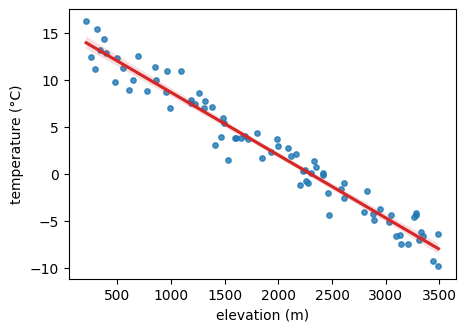

In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)
n = 80
elevation_m = rng.uniform(200, 3500, n)
temp_celsius = 15.0 - 6.5 * (elevation_m / 1000) + rng.normal(0, 1.5, n)
snow_days = 20 + 0.02 * elevation_m + rng.normal(0, 10, n)
df = pd.DataFrame({"elevation_m": elevation_m, "temp_celsius": temp_celsius, "snow_days": snow_days})

fig, ax = plt.subplots(figsize=(5, 3.5))
sns.regplot(data=df, x="elevation_m", y="temp_celsius", ax=ax,
            scatter_kws={"s": 15}, line_kws={"color": "tab:red"})
ax.set_xlabel("elevation (m)")
ax.set_ylabel("temperature (°C)")
plt.show()

## Descriptive statistics and correlation

`describe` summarises each column; `corr` gives the pairwise Pearson correlation. Temperature is strongly anti-correlated with elevation — the lapse rate — while snow days rise with it.

       elevation_m  temp_celsius  snow_days
count        80.00         80.00      80.00
mean       1894.42          2.67      56.92
std         978.78          6.68      21.61
min         209.04         -9.87       6.52
25%        1161.85         -2.89      40.06
50%        1960.25          2.51      57.56
75%        2655.25          8.02      72.30
max        3490.79         16.17      99.78


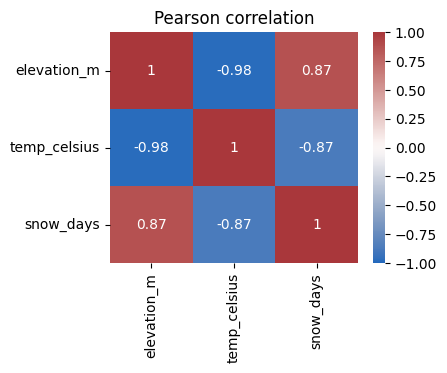

In [2]:
print(df.describe().round(2))

fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(df.corr().round(2), annot=True, cmap="vlag", vmin=-1, vmax=1, ax=ax)
ax.set_title("Pearson correlation")
plt.show()

## The scikit-learn estimator interface

Every scikit-learn model is an object used the same way: instantiate it, `fit` it to a feature matrix `X` and target vector `y`, then `predict`. By convention `X` is two-dimensional with shape (n_samples, n_features) and `y` is one-dimensional. The fitted parameters are stored on attributes ending in an underscore.

In [3]:
from sklearn.linear_model import LinearRegression

X = df[["elevation_m"]]     # 2D feature matrix (note the double brackets)
y = df["temp_celsius"]      # 1D target

model = LinearRegression().fit(X, y)
lapse_rate = model.coef_[0] * 1000          # °C per km
print("recovered lapse rate:", round(lapse_rate, 2), "°C km^-1")
print("intercept (sea-level temp):", round(model.intercept_, 2), "°C")
print("prediction at 2000 m:", round(model.predict(pd.DataFrame({"elevation_m": [2000]}))[0], 2), "°C")

recovered lapse rate: -6.67 °C km^-1
intercept (sea-level temp): 15.31 °C
prediction at 2000 m: 1.96 °C


## Train/test split, RMSE, and R^2

A model must be judged on data it has not seen. `train_test_split` holds out a test set; the root-mean-square error (RMSE) reports the typical error in the target's units, and R^2 the fraction of variance explained.

test RMSE: 1.595 °C
test R^2:  0.947


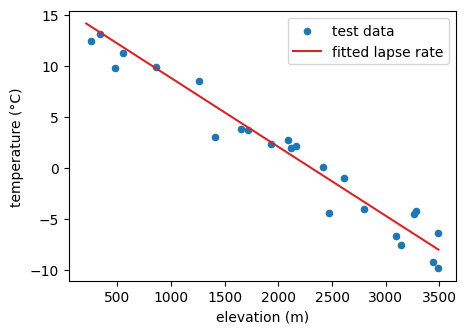

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
model = LinearRegression().fit(X_train, y_train)
y_pred = model.predict(X_test)

print("test RMSE:", round(root_mean_squared_error(y_test, y_pred), 3), "°C")
print("test R^2: ", round(r2_score(y_test, y_pred), 3))

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.scatter(X_test["elevation_m"], y_test, s=20, label="test data")
grid = pd.DataFrame({"elevation_m": np.linspace(X["elevation_m"].min(), X["elevation_m"].max(), 100)})
ax.plot(grid["elevation_m"], model.predict(grid), color="tab:red", label="fitted lapse rate")
ax.set_xlabel("elevation (m)")
ax.set_ylabel("temperature (°C)")
ax.legend()
plt.show()

:::{admonition} Computational-thinking fundamental: evaluate on data the model has not seen
:class: important
The goal of a model is to generalise, so its performance is what it achieves on unseen data — never on the data it was fitted to. A sufficiently flexible model can fit any training set perfectly, including its noise, while predicting new points badly. The train/test split (and, better, cross-validation) exists to measure generalisation rather than memorisation. Reporting a training-set score as "accuracy" is the single most common way a first machine-learning result is wrong.
:::

## Scaling and pipelines

Many estimators (regularised regressions, distance-based methods) require features on comparable scales; `StandardScaler` centres and scales them. A `Pipeline` chains preprocessing and model into one estimator, so the scaler is fitted on the training data only — which is exactly what prevents information from the test set leaking into training.

In [5]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

pipe = make_pipeline(StandardScaler(), LinearRegression())
pipe.fit(X_train, y_train)
print("pipeline test R^2:", round(pipe.score(X_test, y_test), 3))
# for ordinary least squares, scaling leaves predictions unchanged; the habit matters
# for regularised and distance-based models, where unscaled features distort the fit

pipeline test R^2: 0.947


## When generated code lies: scoring on the training data

Asked to "evaluate the model", an assistant fits a flexible model and reports R^2 on the same data it trained on. On a small, noisy sample a high-degree polynomial fits almost perfectly — and predicts new points disastrously.

In [6]:
from sklearn.preprocessing import PolynomialFeatures

rng2 = np.random.default_rng(1)
x_small = np.linspace(0.2, 3.5, 20)
y_small = 15.0 - 6.5 * x_small + rng2.normal(0, 2.0, 20)   # noisy lapse rate, km
Xs = x_small.reshape(-1, 1)
Xs_tr, Xs_te, ys_tr, ys_te = train_test_split(Xs, y_small, test_size=0.4, random_state=0)

overfit = make_pipeline(PolynomialFeatures(degree=10), LinearRegression()).fit(Xs_tr, ys_tr)
print("degree-10 R^2 on TRAINING data:", round(r2_score(ys_tr, overfit.predict(Xs_tr)), 3))

degree-10 R^2 on TRAINING data: 0.99


:::{admonition} Diagnosis: a training score is not performance
:class: warning
The training R^2 near 1.0 says only that the degree-10 polynomial threaded through its own training points; it memorised the noise. Evaluated on held-out data the same model is catastrophic, while the simple linear model — the correct physical form — generalises well. The training score was never evidence of anything; only the test score is.
:::

In [7]:
linear = LinearRegression().fit(Xs_tr, ys_tr)
print("degree-10 R^2 on TEST data:", round(r2_score(ys_te, overfit.predict(Xs_te)), 1))
print("linear    R^2 on TEST data:", round(r2_score(ys_te, linear.predict(Xs_te)), 3))

degree-10 R^2 on TEST data: -1450.0
linear    R^2 on TEST data: 0.984


:::{admonition} Quick exercise: recover the lapse rate honestly
:class: note
Split the `df` data into train and test, fit a `LinearRegression` of `temp_celsius` on `elevation_m`, and report the recovered lapse rate (°C km⁻¹) and the test R^2.
:::

:::{admonition} Solution
:class: note dropdown
```python
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
X = df[["elevation_m"]]; y = df["temp_celsius"]
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=0)
m = LinearRegression().fit(Xtr, ytr)
print(round(m.coef_[0] * 1000, 2), "°C km^-1")
print(round(r2_score(yte, m.predict(Xte)), 3))
```
:::

:::{admonition} Going deeper: cross-validation
:class: seealso dropdown
A single split is noisy. k-fold cross-validation rotates the held-out fold and averages, giving a more stable estimate of generalisation.

```python
from sklearn.model_selection import cross_val_score
scores = cross_val_score(LinearRegression(), X, y, cv=5, scoring="r2")
print(scores.mean(), scores.std())
```
:::

:::{admonition} Going deeper: classification models
:class: seealso dropdown
The same interface covers classifiers. Logistic regression, k-nearest neighbours, and a decision tree all follow fit/predict.

```python
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
clf = LogisticRegression().fit(X_train, y_binary_train)   # e.g. frost / no frost
clf.predict(X_test)
```

Swapping one estimator for another changes one line, not the workflow.
:::

:::{admonition} Going deeper: inferential regression with statsmodels
:class: seealso dropdown
scikit-learn optimises prediction; `statsmodels` reports the inferential statistics — standard errors, confidence intervals, p-values — needed to reason about the lapse-rate estimate itself.

```python
import statsmodels.api as sm
result = sm.OLS(y, sm.add_constant(X)).fit()
print(result.summary())      # coefficients with standard errors and CIs
```
:::

:::{admonition} Going deeper: bootstrap confidence intervals
:class: seealso dropdown
Resampling the data with replacement and refitting many times gives an empirical distribution of any estimate — here the lapse rate — without distributional assumptions.

```python
slopes = []
for _ in range(1000):
    idx = rng.integers(0, len(X), len(X))
    slopes.append(LinearRegression().fit(X.iloc[idx], y.iloc[idx]).coef_[0] * 1000)
low, high = np.percentile(slopes, [2.5, 97.5])   # 95% interval
```
:::

:::{admonition} Takeaways
:class: danger
- Explore before modelling: seaborn plots, `describe`, and `corr` reveal structure and relationships.
- Every scikit-learn estimator follows instantiate → `fit(X, y)` → `predict`, with `X` two-dimensional and `y` one-dimensional.
- Fit on a training set and evaluate on a held-out test set; report RMSE (in target units) and R^2.
- A high training score with a low test score is overfitting — a training score alone is never performance.
- Use `StandardScaler` and a `Pipeline` so preprocessing is fitted on training data only, preventing leakage.
:::

## Resources

- [scikit-learn — Getting started](https://scikit-learn.org/stable/getting_started.html) — the estimator interface, fit/predict, train/test evaluation, and pipelines.
- [seaborn](https://seaborn.pydata.org/) — statistical visualisation on dataframes, including regression and correlation plots.
:::